In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import pathlib
import random
import keras_hub
from keras import ops

### Load Model

In [2]:
model = keras_hub.models.ImageSegmenter.from_preset("sam_huge_sa1b")
model.summary()

Preprocessor: "sam_image_segmenter_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sam_image_converter (SAMImageConverter)                       │               Image size: (1,024, 1,024) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "sam_image_segmenter"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ boxes (InputLayer)            │ (None, None, 2, 2)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ images (InputLayer)           │ (None, 1024, 1024, 3)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ labels (InputLayer)           │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masks (InputLayer)            │ (None, None, None, None,  │               0 │ -                          │
│                               │ 1)                        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ points (InputLayer)           │ (None, None, 2)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sam_backbone (SAMBackbone)    │ [(None, 64, 64, 256),     │     637,032,524 │ boxes[0][0], images[0][0], │
│                               │ (None, 64, 64, 256),      │                 │ labels[0][0], masks[0][0], │
│                               │ (None, 64, 64, 256),      │                 │ points[0][0]               │
│                               │ (None, None, 256)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sam_mask_decoder              │ [(None, 4), (None, 4,     │       4,058,340 │ sam_backbone[0][0],        │
│ (SAMMaskDecoder)              │ 256, 256)]                │                 │ sam_backbone[0][1],        │
│                               │                           │                 │ sam_backbone[0][2],        │
│                               │                           │                 │ sam_backbone[0][3]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 641,090,864 (2.39 GB)

 Trainable params: 641,090,608 (2.39 GB)

 Non-trainable params: 256 (1.00 KB)

In [3]:
model.count_params()

641090864

### Load Image

259153/259153 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


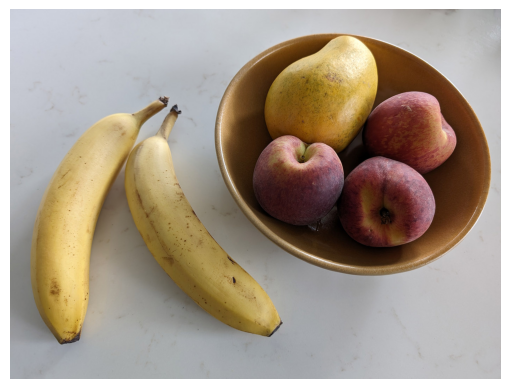

(1054, 1400, 3)


In [4]:
path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)
pil_image = keras.utils.load_img(path)
image_array = keras.utils.img_to_array(pil_image)
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()
print(image_array.shape)

In [5]:
image_size = (1024, 1024)
def resize_and_pad(x):
  return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)
image = resize_and_pad(image_array)
image.shape

TensorShape([1024, 1024, 3])

### Utils

In [6]:
def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

### Point Prompt

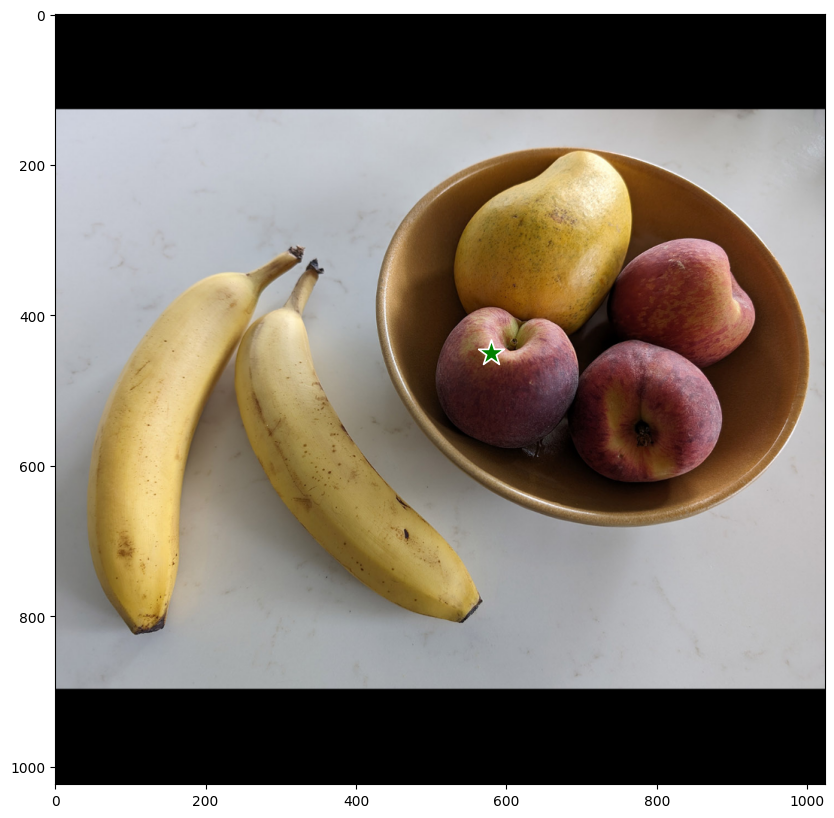

In [7]:
input_point = np.array([[580, 450]])
input_label = np.array([1])
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

In [8]:
outputs = model.predict(
{
"images": ops.expand_dims(image, axis=0),
"points": ops.expand_dims(input_point, axis=0),
"labels": ops.expand_dims(input_label, axis=0),
}
)
outputs

1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step


{'masks': array([[[[-17.809162 , -17.935085 , -18.524815 , ..., -19.919178 ,
           -19.614183 , -20.416517 ],
          [-17.062813 , -20.168932 , -17.57398  , ..., -23.861088 ,
           -22.328465 , -23.541946 ],
          [-18.95099  , -18.624329 , -18.953037 , ..., -19.079733 ,
           -19.932032 , -20.79013  ],
          ...,
          [-20.577295 , -25.836575 , -21.731047 , ..., -22.710903 ,
           -19.539091 , -19.690586 ],
          [-25.147663 , -26.433556 , -25.216038 , ..., -20.130861 ,
           -22.839506 , -20.673496 ],
          [-21.279312 , -28.242897 , -20.202578 , ..., -20.632175 ,
           -19.36867  , -18.58453  ]],
 
         [[-24.981491 , -25.253935 , -25.612614 , ..., -26.034462 ,
           -26.504095 , -27.036674 ],
          [-23.615477 , -27.963614 , -24.10298  , ..., -31.633162 ,
           -30.008495 , -31.61943  ],
          [-25.704643 , -25.559412 , -25.919739 , ..., -24.701088 ,
           -26.672674 , -27.252327 ],
          ...,
    

In [9]:
outputs.keys()

dict_keys(['masks', 'iou_pred'])

In [10]:
outputs["masks"].shape

(1, 4, 256, 256)

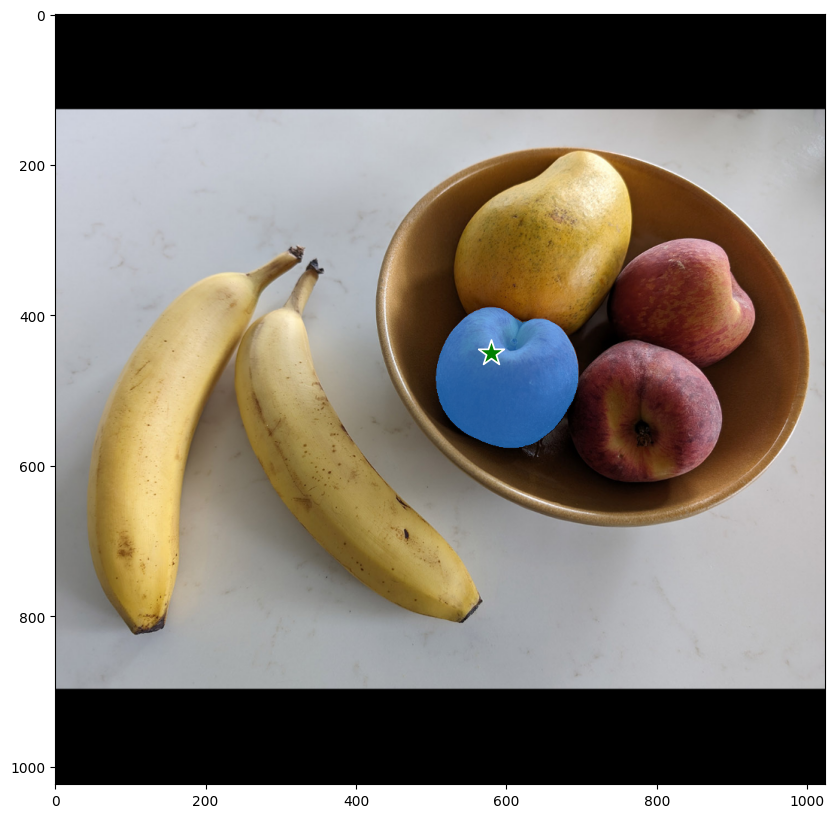

In [11]:
def get_mask(sam_outputs, index=0):
    mask = sam_outputs["masks"][0][index]
    mask = np.expand_dims(mask, axis=-1)
    mask = resize_and_pad(mask)
    return ops.convert_to_numpy(mask) > 0.0

mask = get_mask(outputs, index=0)
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

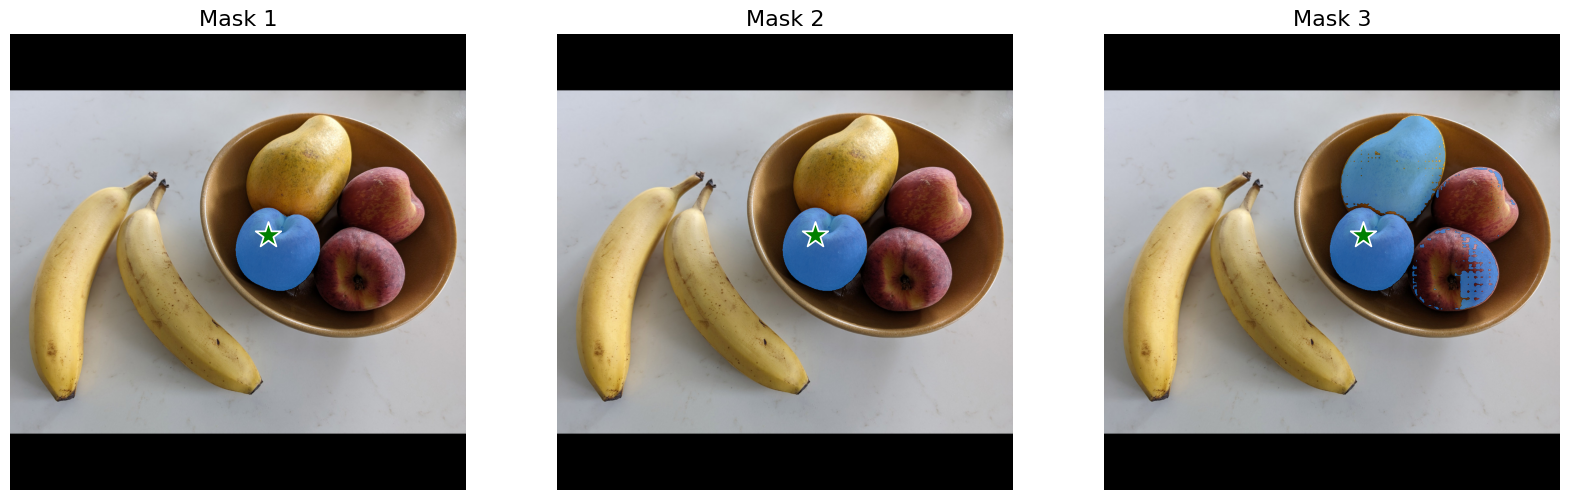

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 60))
masks = outputs["masks"][0][1:]
for i, mask in enumerate(masks):
    show_image(image, axes[i])
    show_points(input_point, axes[i])
    mask = get_mask(outputs, index=i + 1)
    show_mask(mask, axes[i])
    axes[i].set_title(f"Mask {i + 1}", fontsize=16)
    axes[i].axis("off")
plt.show()

### Box Prompt

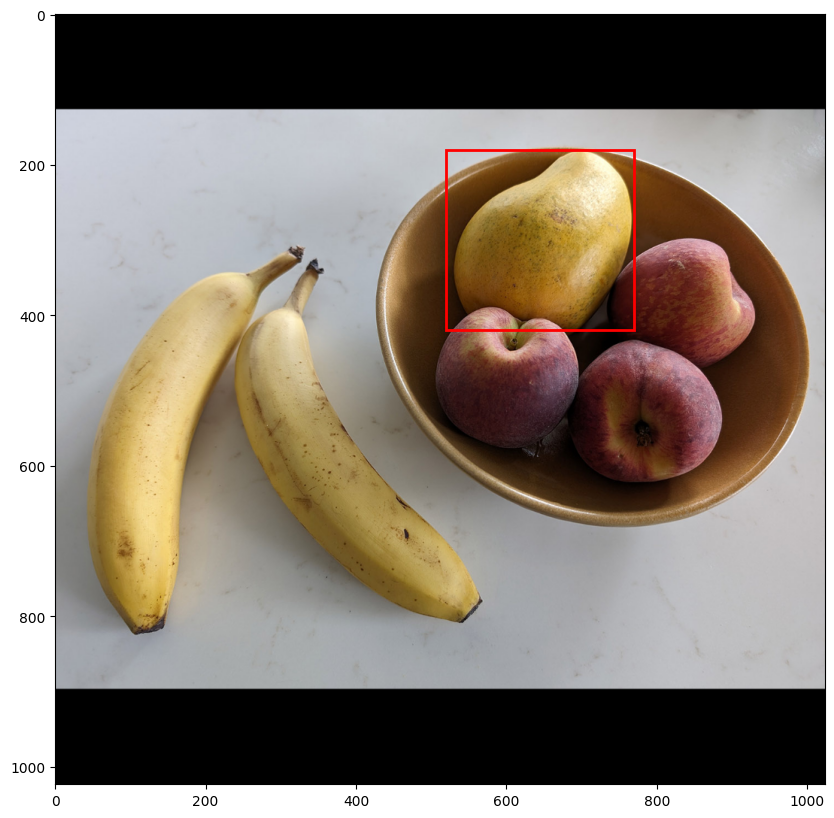

In [15]:
input_box = np.array([[520, 180], [770, 420]])
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_box(input_box, plt.gca())
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


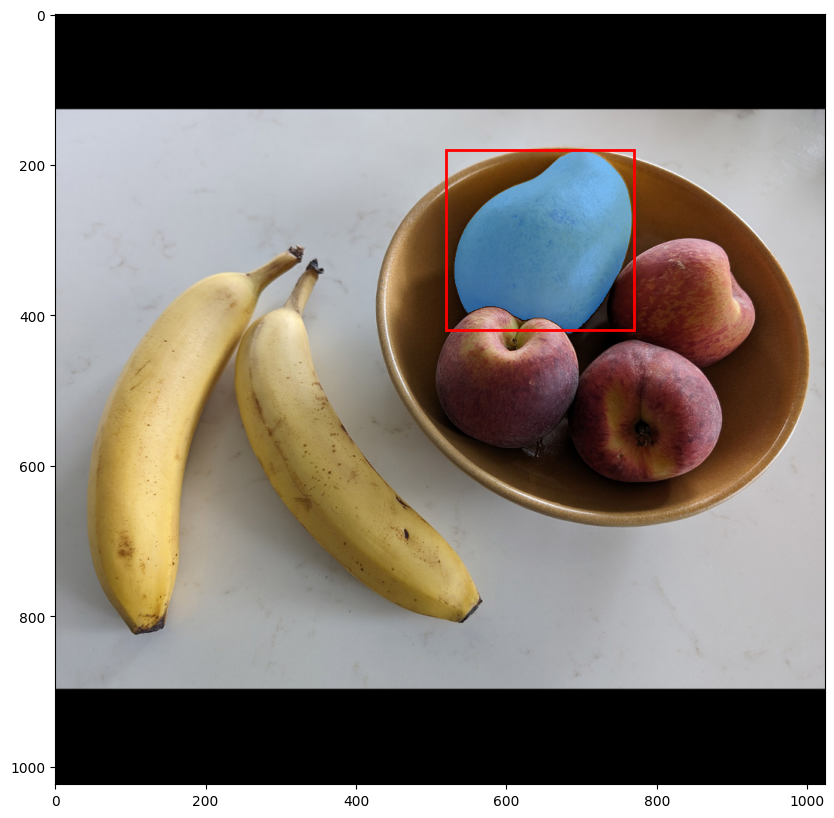

In [16]:
outputs = model.predict({"images": ops.expand_dims(image, axis=0),"boxes": ops.expand_dims(input_box, axis=(0, 1)),})
mask = get_mask(outputs, 0)
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_box(input_box, plt.gca())
plt.show()

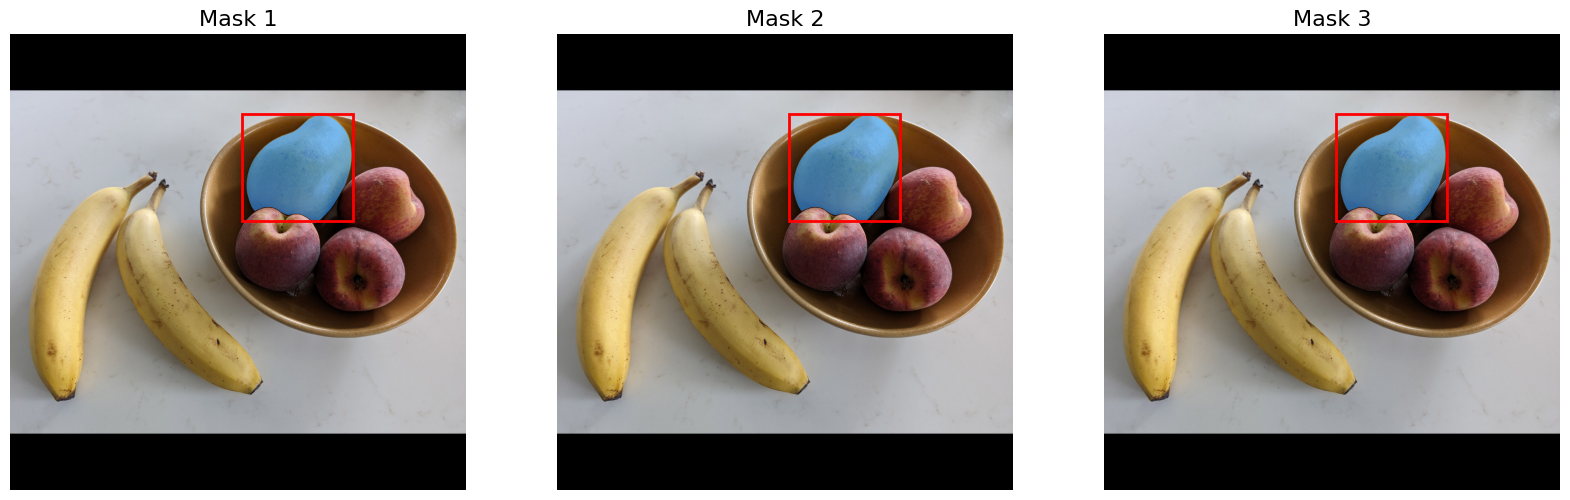

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 60))
masks = outputs["masks"][0][1:]
for i, mask in enumerate(masks):
    show_image(image, axes[i])
    show_box(input_box, axes[i])
    mask = get_mask(outputs, index=i + 1)
    show_mask(mask, axes[i])
    axes[i].set_title(f"Mask {i + 1}", fontsize=16)
    axes[i].axis("off")
plt.show()